In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.optimize import curve_fit
import os
import glob
import pandas as pd

Using beam parameters at 1284 MHz (central frequency)
  Sigma_x: 18.99 arcsec
  Sigma_y: 18.75 arcsec
  Sigma_avg: 18.87 arcsec
  FWHM_avg: 44.44 arcsec = 0.741 arcmin

Overlap at 25% response level:
  Radius at 25% response: 31.42 arcsec
  Beam separation: 62.84 arcsec = 1.047 arcmin
  This is 141.4% of FWHM

Beam positions (arcsec):
  Beam 1: (0.00, 36.28)
  Beam 2: (-31.42, -18.14)
  Beam 3: (31.42, -18.14)


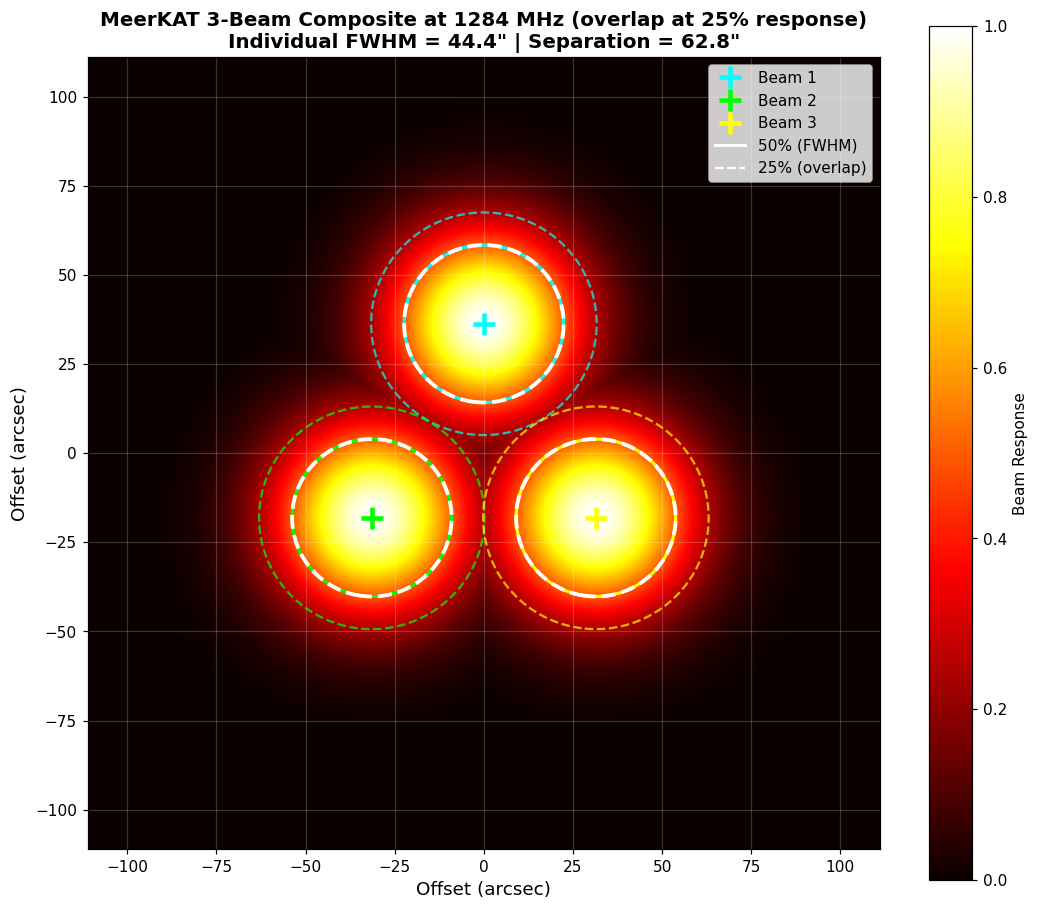


COMPOSITE BEAM SUMMARY at 1284 MHz (25% Response Overlap)
Individual beam FWHM: 44.44 arcsec = 0.741 arcmin
Overlap level: 25% response (beam response = 0.25 at overlap)
Radius at 25%: 31.42 arcsec
Beam separation: 62.84 arcsec = 1.047 arcmin
Triangle side length: 62.84 arcsec

Effective FoV (≥50% response):
  Area: 4633.6 arcsec² = 1.2871 arcmin²
  Equivalent diameter: 76.8 arcsec

Effective FoV (≥25% response):
  Area: 9267.2 arcsec² = 2.5742 arcmin²
  Equivalent diameter: 108.6 arcsec

BEAM SEPARATIONS (Equilateral Triangle)
Beam 1 ↔ Beam 2: 62.84 arcsec = 1.047 arcmin
Beam 2 ↔ Beam 3: 62.84 arcsec = 1.047 arcmin
Beam 1 ↔ Beam 3: 62.84 arcsec = 1.047 arcmin


In [2]:
# Create composite beam from 3 tied-array beams with overlap at 25% response level
# Using beam parameters at 1284 MHz (central frequency of 856-1712 MHz band)

# Load beam parameters from CSV
beam_params = pd.read_csv('/Users/xuziying/Downloads/MeerKAT_beam_n_comp/beam_parameters.csv')

# Get parameters at 1284 MHz (central frequency)
central_freq = 1284.0
params_1284 = beam_params[beam_params['freq_MHz'] == central_freq].iloc[0]

sigma_h = params_1284['sigma_x']  # horizontal sigma in arcsec
sigma_v = params_1284['sigma_y']  # vertical sigma in arcsec
sigma_avg = params_1284['sigma_avg']

fwhm_h = params_1284['fwhm_x']
fwhm_v = params_1284['fwhm_y']
fwhm_avg = params_1284['fwhm_avg']

print(f"Using beam parameters at {central_freq:.0f} MHz (central frequency)")
print(f"  Sigma_x: {sigma_h:.2f} arcsec")
print(f"  Sigma_y: {sigma_v:.2f} arcsec")
print(f"  Sigma_avg: {sigma_avg:.2f} arcsec")
print(f"  FWHM_avg: {fwhm_avg:.2f} arcsec = {fwhm_avg/60:.3f} arcmin")

# Define 2D Gaussian beam function
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp=1.0):
    """2D Gaussian beam centered at (x0, y0)"""
    return amp * np.exp(-0.5 * (((x - x0) / sigma_x)**2 + ((y - y0) / sigma_y)**2))

# === OVERLAP AT 25% RESPONSE LEVEL ===
# For a Gaussian: response = exp(-0.5 * r²/σ²) = 0.25
# Solving for r: r = σ * sqrt(-2 * ln(0.25)) ≈ 1.665 * σ
overlap_response_level = 0.25
radius_at_overlap = sigma_avg * np.sqrt(-2 * np.log(overlap_response_level))

# Beam separation = 2 * radius at overlap level (so 25% contours just touch)
beam_separation = 2 * radius_at_overlap

print(f"\nOverlap at {overlap_response_level*100:.0f}% response level:")
print(f"  Radius at 25% response: {radius_at_overlap:.2f} arcsec")
print(f"  Beam separation: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")
print(f"  This is {beam_separation/fwhm_avg*100:.1f}% of FWHM")

# Create coordinate grid (in arcsec)
grid_size = fwhm_avg * 2.5  # enough to show full composite beam
n_pixels = 500
x = np.linspace(-grid_size, grid_size, n_pixels)
y = np.linspace(-grid_size, grid_size, n_pixels)
X, Y = np.meshgrid(x, y)

# Triangle beam arrangement (equilateral triangle centered at origin)
# Distance from center to each vertex
R = beam_separation / np.sqrt(3)  # for equilateral triangle with given side length

# Beam positions (one at top, two at bottom)
beam_positions = np.array([
    [0, R],                              # Top
    [-beam_separation/2, -R/2],          # Bottom-left
    [beam_separation/2, -R/2]            # Bottom-right
])

print(f"\nBeam positions (arcsec):")
for i, (bx, by) in enumerate(beam_positions):
    print(f"  Beam {i+1}: ({bx:.2f}, {by:.2f})")

# Create individual beams
beam1 = gaussian_2d(X, Y, beam_positions[0][0], beam_positions[0][1], sigma_h, sigma_v)
beam2 = gaussian_2d(X, Y, beam_positions[1][0], beam_positions[1][1], sigma_h, sigma_v)
beam3 = gaussian_2d(X, Y, beam_positions[2][0], beam_positions[2][1], sigma_h, sigma_v)

# Composite beam (maximum envelope)
composite = np.maximum(np.maximum(beam1, beam2), beam3)

# === SINGLE PLOT ===
fig, ax = plt.subplots(figsize=(10, 10), dpi=110)

# Plot composite beam
im = ax.imshow(composite, extent=[-grid_size, grid_size, -grid_size, grid_size],
               origin='lower', cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Beam Response', shrink=0.8)

# Draw contours for each individual beam
colors = ['cyan', 'lime', 'yellow']
labels = ['Beam 1', 'Beam 2', 'Beam 3']
for i, (beam, pos, color, label) in enumerate(zip([beam1, beam2, beam3], 
                                                   beam_positions, colors, labels)):
    # FWHM contour (50% of peak)
    ax.contour(X, Y, beam, levels=[0.5], colors=[color], linestyles='-', linewidths=2)
    # 25% contour (overlap boundary)
    ax.contour(X, Y, beam, levels=[0.25], colors=[color], linestyles='--', linewidths=1.5, alpha=0.7)
    # Mark beam center
    ax.plot(pos[0], pos[1], '+', color=color, markersize=15, markeredgewidth=3, label=label)

# Draw composite FWHM contour
ax.contour(X, Y, composite, levels=[0.5], colors='white', linestyles='--', linewidths=2.5)

# Add legend for contour levels
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='white', linestyle='-', linewidth=2, label='50% (FWHM)'),
    Line2D([0], [0], color='white', linestyle='--', linewidth=1.5, label='25% (overlap)')
]

# Add labels
ax.set_xlabel('Offset (arcsec)', fontsize=12)
ax.set_ylabel('Offset (arcsec)', fontsize=12)
ax.set_title(f'MeerKAT 3-Beam Composite at {central_freq:.0f} MHz (overlap at 25% response)\n'
             f'Individual FWHM = {fwhm_avg:.1f}" | Separation = {beam_separation:.1f}"', 
             fontsize=13, fontweight='bold')

handles, labels_leg = ax.get_legend_handles_labels()
handles.extend(legend_elements)
ax.legend(handles=handles, loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print(f"COMPOSITE BEAM SUMMARY at {central_freq:.0f} MHz (25% Response Overlap)")
print("="*60)
print(f"Individual beam FWHM: {fwhm_avg:.2f} arcsec = {fwhm_avg/60:.3f} arcmin")
print(f"Overlap level: 25% response (beam response = 0.25 at overlap)")
print(f"Radius at 25%: {radius_at_overlap:.2f} arcsec")
print(f"Beam separation: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")
print(f"Triangle side length: {beam_separation:.2f} arcsec")

# Calculate effective FoV
half_max_mask = composite >= 0.5
quarter_max_mask = composite >= 0.25
effective_area_50 = np.sum(half_max_mask) * (2 * grid_size / n_pixels)**2
effective_area_25 = np.sum(quarter_max_mask) * (2 * grid_size / n_pixels)**2
print(f"\nEffective FoV (≥50% response):")
print(f"  Area: {effective_area_50:.1f} arcsec² = {effective_area_50/3600:.4f} arcmin²")
print(f"  Equivalent diameter: {2*np.sqrt(effective_area_50/np.pi):.1f} arcsec")
print(f"\nEffective FoV (≥25% response):")
print(f"  Area: {effective_area_25:.1f} arcsec² = {effective_area_25/3600:.4f} arcmin²")
print(f"  Equivalent diameter: {2*np.sqrt(effective_area_25/np.pi):.1f} arcsec")

print("\n" + "="*60)
print("BEAM SEPARATIONS (Equilateral Triangle)")
print("="*60)
print(f"Beam 1 ↔ Beam 2: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")
print(f"Beam 2 ↔ Beam 3: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")
print(f"Beam 1 ↔ Beam 3: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")

In [34]:
# filepath: /Users/xuziying/Desktop/VScode/FRB_population/MeerKat_beams_freq.ipynb
# Define Gaussian function
def gaussian(x, amp, mu, sigma, offset):
    """Gaussian function with offset"""
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2) + offset

def extract_freq_from_filename(filepath):
    """Extract frequency (in MHz) from filename like 'Meerkat_882.75MHz.fits'"""
    import re
    filename = os.path.basename(filepath)
    # Match pattern like "882.75" before "MHz.fits"
    # Pattern: one or more digits, optionally followed by decimal point and more digits, then "MHz"
    match = re.search(r'(\d+\.?\d*)MHz\.fits', filename)
    if match:
        return float(match.group(1))
    return 0.0

def fit_beam_gaussian(fits_path):
    """
    Fit Gaussian to a beam FITS file and return beam parameters.
    """
    result = {
        'filename': os.path.basename(fits_path),
        'freq_MHz': extract_freq_from_filename(fits_path),
        'sigma_x': np.nan,
        'sigma_y': np.nan,
        'sigma_avg': np.nan,
        'fwhm_x': np.nan,
        'fwhm_y': np.nan,
        'fwhm_avg': np.nan,
        'fit_success_x': False,
        'fit_success_y': False
    }
    
    try:
        hdu = fits.open(fits_path)
        data = hdu[0].data
        header = hdu[0].header
        
        # Handle different data dimensions
        if data.ndim == 4:
            plot_data = data[0, 0, :, :]
        elif data.ndim == 3:
            plot_data = data[0, :, :]
        else:
            plot_data = data
        
        # Get pixel scale from header
        cdelt1 = np.abs(header['CDELT1']) * 3600  # deg to arcsec per pixel
        cdelt2 = np.abs(header['CDELT2']) * 3600
        
        # Find peak location
        peak_idx = np.unravel_index(np.argmax(plot_data), plot_data.shape)
        cy, cx = peak_idx[0], peak_idx[1]
        
        # === FIT HORIZONTAL (X) ===
        x_pixels = np.arange(plot_data.shape[1])
        x_arcsec = (x_pixels - cx) * cdelt1
        y_horizontal = plot_data[cy, :]
        
        amp_guess = y_horizontal.max() - y_horizontal.min()
        offset_guess = y_horizontal.min()
        half_max = (y_horizontal.max() + y_horizontal.min()) / 2
        above_half = np.where(y_horizontal > half_max)[0]
        if len(above_half) > 0:
            sigma_guess = (above_half[-1] - above_half[0]) * cdelt1 / 2.355
        else:
            sigma_guess = 20 * cdelt1
        
        try:
            p0_h = [amp_guess, 0, sigma_guess, offset_guess]
            bounds_h = ([0, -len(x_pixels)*cdelt1/2, 0.1, -np.inf], 
                        [np.inf, len(x_pixels)*cdelt1/2, len(x_pixels)*cdelt1/2, np.inf])
            popt_h, _ = curve_fit(gaussian, x_arcsec, y_horizontal, 
                                  p0=p0_h, bounds=bounds_h, maxfev=10000)
            result['sigma_x'] = np.abs(popt_h[2])
            result['fwhm_x'] = 2.355 * result['sigma_x']
            result['fit_success_x'] = True
        except Exception as e:
            print(f"  Horizontal fit failed for {os.path.basename(fits_path)}: {e}")
        
        # === FIT VERTICAL (Y) ===
        y_pixels = np.arange(plot_data.shape[0])
        y_arcsec = (y_pixels - cy) * cdelt2
        y_vertical = plot_data[:, cx]
        
        amp_guess_v = y_vertical.max() - y_vertical.min()
        offset_guess_v = y_vertical.min()
        above_half_v = np.where(y_vertical > (y_vertical.max() + y_vertical.min()) / 2)[0]
        if len(above_half_v) > 0:
            sigma_guess_v = (above_half_v[-1] - above_half_v[0]) * cdelt2 / 2.355
        else:
            sigma_guess_v = 20 * cdelt2
        
        try:
            p0_v = [amp_guess_v, 0, sigma_guess_v, offset_guess_v]
            bounds_v = ([0, -len(y_pixels)*cdelt2/2, 0.1, -np.inf], 
                        [np.inf, len(y_pixels)*cdelt2/2, len(y_pixels)*cdelt2/2, np.inf])
            popt_v, _ = curve_fit(gaussian, y_arcsec, y_vertical, 
                                  p0=p0_v, bounds=bounds_v, maxfev=10000)
            result['sigma_y'] = np.abs(popt_v[2])
            result['fwhm_y'] = 2.355 * result['sigma_y']
            result['fit_success_y'] = True
        except Exception as e:
            print(f"  Vertical fit failed for {os.path.basename(fits_path)}: {e}")
        
        # Calculate average FWHM
        if result['fit_success_x'] and result['fit_success_y']:
            result['fwhm_avg'] = (result['fwhm_x'] + result['fwhm_y']) / 2
            result['sigma_avg'] = (result['sigma_x'] + result['sigma_y']) / 2
        
        hdu.close()
        
    except Exception as e:
        print(f"Error processing {fits_path}: {e}")
    
    return result


# === PROCESS ALL FITS FILES IN FOLDER ===

beam_folder = '/Users/xuziying/Downloads/MeerKat_beams'

# Find all FITS files and sort by frequency (extracted from filename)
fits_files = glob.glob(os.path.join(beam_folder, '*.fits'))
fits_files = sorted(fits_files, key=extract_freq_from_filename)

print(f"Found {len(fits_files)} FITS files in {beam_folder}")
print("\nFiles sorted by frequency:")
for f in fits_files:
    print(f"  {extract_freq_from_filename(f):.2f} MHz <- {os.path.basename(f)}")
print("="*70)

# Process each file
results = []
for fits_path in fits_files:
    print(f"Processing: {os.path.basename(fits_path)}")
    result = fit_beam_gaussian(fits_path)
    results.append(result)

# Create DataFrame
df = pd.DataFrame(results)

# Sort by frequency
df = df.sort_values('freq_MHz').reset_index(drop=True)

# Calculate beam_separation based on sigma at reference frequency
overlap_response_level = 0.25
# Use the middle frequency or average sigma
sigma_ref = df['sigma_avg'].mean()
radius_at_overlap = sigma_ref * np.sqrt(-2 * np.log(overlap_response_level))
df['beam_sep'] = 2 * radius_at_overlap

# Display results
print("\n" + "="*70)
print("BEAM PARAMETERS FOR ALL FREQUENCIES (sorted by frequency)")
print("="*70)
print(df.to_string(index=False))

# Save to CSV
output_columns = ['freq_MHz', 'sigma_x', 'sigma_y', 'sigma_avg', 'fwhm_x', 'fwhm_y', 'fwhm_avg', 'beam_sep']
df_export = df[output_columns].copy()

output_csv = os.path.join(beam_folder, 'beam_parameters.csv')
df_export.to_csv(output_csv, index=False)
print(f"\nResults saved to: {output_csv}")
print(f"Exported columns: {output_columns}")
print(f"Note: All sigma and FWHM values are in arcsec")

Found 16 FITS files in /Users/xuziying/Downloads/MeerKat_beams

Files sorted by frequency:
  882.75 MHz <- Meerkat_882.75MHz.fits
  936.25 MHz <- Meerkat_936.25MHz.fits
  989.75 MHz <- Meerkat_989.75MHz.fits
  1043.25 MHz <- Meerkat_1043.25MHz.fits
  1096.75 MHz <- Meerkat_1096.75MHz.fits
  1150.25 MHz <- Meerkat_1150.25MHz.fits
  1203.75 MHz <- Meerkat_1203.75MHz.fits
  1257.25 MHz <- Meerkat_1257.25MHz.fits
  1310.75 MHz <- Meerkat_1310.75MHz.fits
  1364.25 MHz <- Meerkat_1364.25MHz.fits
  1417.75 MHz <- Meerkat_1417.75MHz.fits
  1471.25 MHz <- Meerkat_1471.25MHz.fits
  1524.75 MHz <- Meerkat_1524.75MHz.fits
  1578.25 MHz <- Meerkat_1578.25MHz.fits
  1631.75 MHz <- Meerkat_1631.75MHz.fits
  1685.25 MHz <- Meerkat_1685.25MHz.fits
Processing: Meerkat_882.75MHz.fits
Processing: Meerkat_936.25MHz.fits
Processing: Meerkat_989.75MHz.fits
Processing: Meerkat_1043.25MHz.fits
Processing: Meerkat_1096.75MHz.fits
Processing: Meerkat_1150.25MHz.fits
Processing: Meerkat_1203.75MHz.fits
Processing

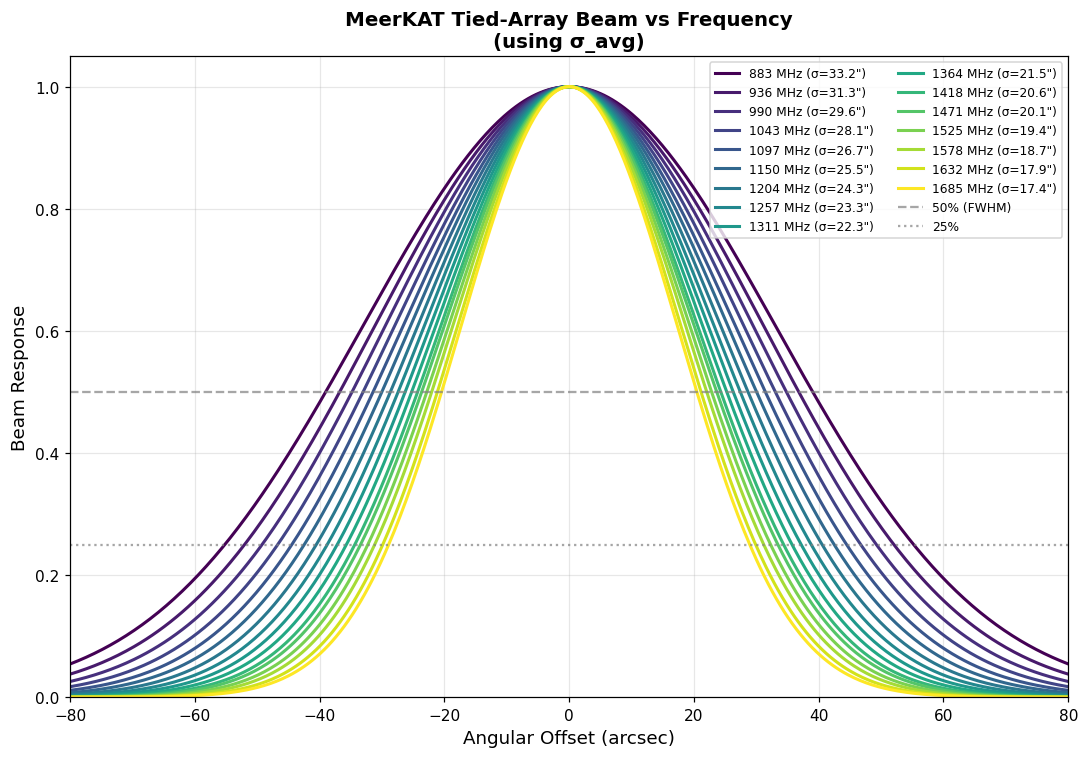

BEAM SIZE SUMMARY
Frequency range: 883 - 1685 MHz
FWHM range: 40.94 - 78.09 arcsec
Sigma range: 17.38 - 33.16 arcsec


In [35]:
# === PLOT GAUSSIAN BEAM PROFILES AT DIFFERENT FREQUENCIES ===

# Load beam parameters from CSV
beam_params = pd.read_csv('/Users/xuziying/Downloads/MeerKat_beams/beam_parameters.csv')

# Create angular offset array (in arcsec)
theta = np.linspace(-80, 80, 500)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7), dpi=110)

# Color map for different frequencies
colors = plt.cm.viridis(np.linspace(0, 1, len(beam_params)))

# Plot all frequencies
for i, row in beam_params.iterrows():
    freq = row['freq_MHz']
    sigma = row['sigma_avg']
    
    # Gaussian beam response
    response = np.exp(-0.5 * (theta / sigma)**2)
    
    ax.plot(theta, response, color=colors[i], linewidth=2, 
            label=f'{freq:.0f} MHz (σ={sigma:.1f}")')

# Add reference lines
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='50% (FWHM)')
ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='25%')

ax.set_xlabel('Angular Offset (arcsec)', fontsize=12)
ax.set_ylabel('Beam Response', fontsize=12)
ax.set_title('MeerKAT Tied-Array Beam vs Frequency\n(using σ_avg)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(-80, 80)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Print summary
print("="*60)
print("BEAM SIZE SUMMARY")
print("="*60)
print(f"Frequency range: {beam_params['freq_MHz'].min():.0f} - {beam_params['freq_MHz'].max():.0f} MHz")
print(f"FWHM range: {beam_params['fwhm_avg'].min():.2f} - {beam_params['fwhm_avg'].max():.2f} arcsec")
print(f"Sigma range: {beam_params['sigma_avg'].min():.2f} - {beam_params['sigma_avg'].max():.2f} arcsec")

Found 16 FITS files (sorted by frequency)
Files in order:
  882.75 MHz <- Meerkat_882.75MHz.fits
  936.25 MHz <- Meerkat_936.25MHz.fits
  989.75 MHz <- Meerkat_989.75MHz.fits
  1043.25 MHz <- Meerkat_1043.25MHz.fits
  1096.75 MHz <- Meerkat_1096.75MHz.fits
  1150.25 MHz <- Meerkat_1150.25MHz.fits
  1203.75 MHz <- Meerkat_1203.75MHz.fits
  1257.25 MHz <- Meerkat_1257.25MHz.fits
  1310.75 MHz <- Meerkat_1310.75MHz.fits
  1364.25 MHz <- Meerkat_1364.25MHz.fits
  1417.75 MHz <- Meerkat_1417.75MHz.fits
  1471.25 MHz <- Meerkat_1471.25MHz.fits
  1524.75 MHz <- Meerkat_1524.75MHz.fits
  1578.25 MHz <- Meerkat_1578.25MHz.fits
  1631.75 MHz <- Meerkat_1631.75MHz.fits
  1685.25 MHz <- Meerkat_1685.25MHz.fits
Processing (1/16): Meerkat_882.75MHz.fits -> 882.8 MHz
Processing (2/16): Meerkat_936.25MHz.fits -> 936.2 MHz
Processing (3/16): Meerkat_989.75MHz.fits -> 989.8 MHz
Processing (4/16): Meerkat_1043.25MHz.fits -> 1043.2 MHz
Processing (5/16): Meerkat_1096.75MHz.fits -> 1096.8 MHz
Processing (6

<ipython-input-38-ec4d57aaa983>:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.95])


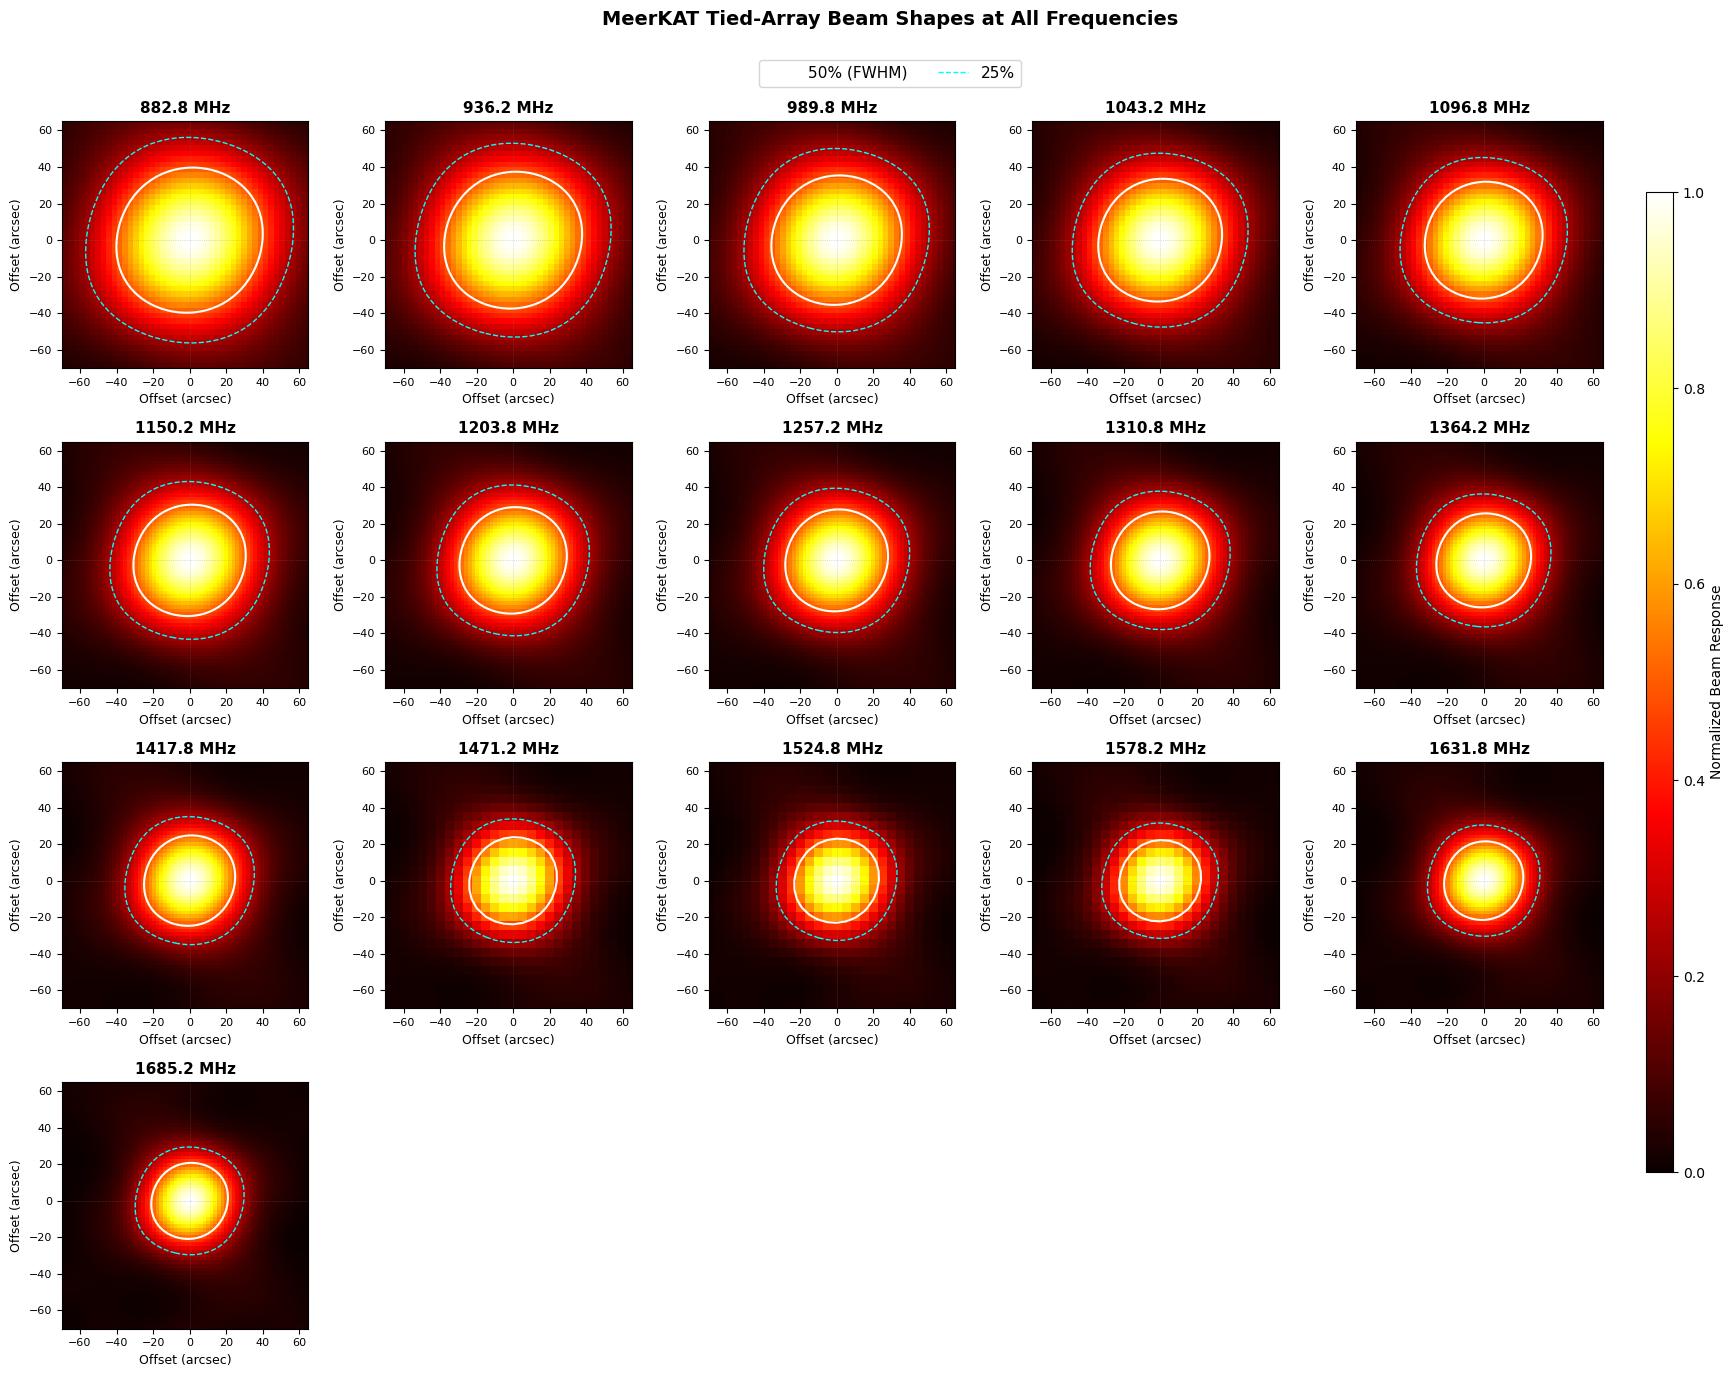


Plotted 16 beam images
White contour = 50% (FWHM), Cyan dashed = 25%


In [38]:
# === PLOT ALL BEAM IMAGES FROM FITS FILES ===

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import glob
import re
from matplotlib.lines import Line2D

# Path to the beam folder
beam_folder = '/Users/xuziying/Downloads/MeerKat_beams'

# Get all FITS files
fits_files = glob.glob(os.path.join(beam_folder, '*.fits'))

# Extract frequency from filename and sort by frequency
def extract_freq_from_filename(filepath):
    """Extract frequency (in MHz) from filename like 'Meerkat_882.75MHz.fits'"""
    filename = os.path.basename(filepath)
    # Match pattern like "882.75" before "MHz.fits"
    match = re.search(r'(\d+\.?\d*)MHz\.fits', filename)
    if match:
        return float(match.group(1))
    return 0.0

# Sort files by frequency (not alphabetically)
fits_files = sorted(fits_files, key=extract_freq_from_filename)
n_files = len(fits_files)

print(f"Found {n_files} FITS files (sorted by frequency)")
print("Files in order:")
for f in fits_files:
    print(f"  {extract_freq_from_filename(f):.2f} MHz <- {os.path.basename(f)}")

# Calculate grid size
n_cols = 5
n_rows = int(np.ceil(n_files / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows), dpi=100)
axes = axes.flatten()

for i, fits_path in enumerate(fits_files):
    # Extract frequency from filename
    freq = extract_freq_from_filename(fits_path)
    freq_label = f'{freq:.1f} MHz'
    
    print(f"Processing ({i+1}/{n_files}): {os.path.basename(fits_path)} -> {freq_label}")
    
    # Read FITS file
    with fits.open(fits_path) as hdu:
        data = hdu[0].data
        header = hdu[0].header
        
        # Handle different data dimensions
        if data.ndim == 4:
            plot_data = data[0, 0, :, :]
        elif data.ndim == 3:
            plot_data = data[0, :, :]
        else:
            plot_data = data
        
        # Get pixel scale (convert to arcsec)
        cdelt1 = np.abs(header.get('CDELT1', 1)) * 3600  # deg to arcsec
        cdelt2 = np.abs(header.get('CDELT2', 1)) * 3600
        
        # Find peak location for centering
        peak_idx = np.unravel_index(np.argmax(plot_data), plot_data.shape)
        cy, cx = peak_idx[0], peak_idx[1]
        
        # Create coordinate arrays centered on peak
        ny, nx = plot_data.shape
        x_arcsec = (np.arange(nx) - cx) * cdelt1
        y_arcsec = (np.arange(ny) - cy) * cdelt2
        extent = [x_arcsec[0], x_arcsec[-1], y_arcsec[0], y_arcsec[-1]]
        
        # Normalize data
        plot_data_norm = plot_data / plot_data.max()
    
    # Plot
    ax = axes[i]
    im = ax.imshow(plot_data_norm, origin='lower', extent=extent, 
                   cmap='hot', vmin=0, vmax=1)
    
    # Add contours at key levels
    contour_levels = [0.25, 0.5]
    contour_colors = ['cyan', 'white']
    ax.contour(x_arcsec, y_arcsec, plot_data_norm, levels=contour_levels, 
               colors=contour_colors, linewidths=[1, 1.5], linestyles=['--', '-'])
    
    # Labels
    ax.set_title(freq_label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Offset (arcsec)', fontsize=9)
    ax.set_ylabel('Offset (arcsec)', fontsize=9)
    ax.set_xlim(-70, 65)  # Changed from -80, 80
    ax.set_ylim(-70, 65)  # Changed from -80, 80
    ax.tick_params(labelsize=8)
    
    # Crosshairs at center
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

# Hide unused subplots
for j in range(n_files, len(axes)):
    axes[j].axis('off')

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Normalized Beam Response', fontsize=10)

# Add legend for contours
legend_elements = [
    Line2D([0], [0], color='white', linestyle='-', linewidth=1.5, label='50% (FWHM)'),
    Line2D([0], [0], color='cyan', linestyle='--', linewidth=1, label='25%')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11, 
           bbox_to_anchor=(0.5, 0.95))

fig.suptitle('MeerKAT Tied-Array Beam Shapes at All Frequencies', 
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 0.91, 0.95])
plt.show()

print(f"\nPlotted {n_files} beam images")
print("White contour = 50% (FWHM), Cyan dashed = 25%")

In [30]:
f0 = 856
BW = 856
n_chan = 16
freq = []
for i in range(n_chan):
    freq.append(f0 + BW/(2*n_chan) + i * (BW / n_chan))
print(freq) 
for i in range (n_chan):
    print(f"Meerkat_{freq[i]}MHz")

[882.75, 936.25, 989.75, 1043.25, 1096.75, 1150.25, 1203.75, 1257.25, 1310.75, 1364.25, 1417.75, 1471.25, 1524.75, 1578.25, 1631.75, 1685.25]
Meerkat_882.75MHz
Meerkat_936.25MHz
Meerkat_989.75MHz
Meerkat_1043.25MHz
Meerkat_1096.75MHz
Meerkat_1150.25MHz
Meerkat_1203.75MHz
Meerkat_1257.25MHz
Meerkat_1310.75MHz
Meerkat_1364.25MHz
Meerkat_1417.75MHz
Meerkat_1471.25MHz
Meerkat_1524.75MHz
Meerkat_1578.25MHz
Meerkat_1631.75MHz
Meerkat_1685.25MHz


In [58]:
# === GENERATE 1 FRB AND GET BEAM RESPONSE AT ALL FREQUENCIES ===

import numpy as np
import pandas as pd

# Load beam parameters from CSV
beam_params = pd.read_csv('/Users/xuziying/Downloads/MeerKat_beams/beam_parameters.csv')

# Get beam separation (use the value from CSV)
beam_sep = beam_params['beam_sep'].iloc[0]

# Set up triangular beam arrangement (equilateral triangle)
R = beam_sep / np.sqrt(3)
beam_positions = np.array([
    [0, R],                    # Top
    [-beam_sep/2, -R/2],       # Bottom-left
    [beam_sep/2, -R/2]         # Bottom-right
])

# === FUNCTION TO SAMPLE 1 FRB IN TRIANGLE ===
def sample_one_frb_in_triangle(beam_positions):
    """Sample one random FRB position within the triangular region."""
    def point_in_triangle(p, v0, v1, v2):
        def sign(p1, p2, p3):
            return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])
        d1 = sign(p, v0, v1)
        d2 = sign(p, v1, v2)
        d3 = sign(p, v2, v0)
        has_neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
        has_pos = (d1 > 0) or (d2 > 0) or (d3 > 0)
        return not (has_neg and has_pos)
    
    x_min, x_max = beam_positions[:, 0].min(), beam_positions[:, 0].max()
    y_min, y_max = beam_positions[:, 1].min(), beam_positions[:, 1].max()
    
    while True:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        if point_in_triangle([x, y], beam_positions[0], beam_positions[1], beam_positions[2]):
            return x, y

def get_beam_response(x, y, beam_positions, sigma_x, sigma_y):
    """Calculate maximum beam response at position (x, y)."""
    responses = []
    for bx, by in beam_positions:
        response = np.exp(-0.5 * (((x - bx)/sigma_x)**2 + ((y - by)/sigma_y)**2))
        responses.append(response)
    return np.max(responses)


In [ ]:

# === GENERATE 1 FRB ===
np.random.seed(None)  # Use random seed (remove for reproducibility)
frb_x, frb_y = sample_one_frb_in_triangle(beam_positions)

# print(f"FRB Position: x = {frb_x:.2f} arcsec, y = {frb_y:.2f} arcsec")

# === GET BEAM RESPONSE AT ALL FREQUENCIES ===
frequencies = beam_params['freq_MHz'].tolist()
beam_responses = []

for idx, row in beam_params.iterrows():
    response = get_beam_response(frb_x, frb_y, beam_positions, row['sigma_x'], row['sigma_y'])
    beam_responses.append(response)

# # Print results
# print(f"\nBeam responses at {len(frequencies)} frequencies:")
# print(f"Frequencies (MHz): {frequencies}")
# print(f"Beam responses:    {[f'{r:.4f}' for r in beam_responses]}")

# # As simple lists
# print("\n# Copy-paste ready:")
# print(f"freq_list = {frequencies}")
# print(f"response_list = {beam_responses}")

FRB Position: x = -2.15 arcsec, y = -8.01 arcsec

Beam responses at 16 frequencies:
Frequencies (MHz): [882.75, 936.25, 989.75, 1043.25, 1096.75, 1150.25, 1203.75, 1257.25, 1310.75, 1364.25, 1417.75, 1471.25, 1524.75, 1578.25, 1631.75, 1685.25]
Beam responses:    ['0.4799', '0.4384', '0.3990', '0.3618', '0.3266', '0.2885', '0.2556', '0.2255', '0.1981', '0.1733', '0.1511', '0.1387', '0.1198', '0.1030', '0.0839', '0.0716']

# Copy-paste ready:
freq_list = [882.75, 936.25, 989.75, 1043.25, 1096.75, 1150.25, 1203.75, 1257.25, 1310.75, 1364.25, 1417.75, 1471.25, 1524.75, 1578.25, 1631.75, 1685.25]
response_list = [0.47989400904486, 0.43844248770200345, 0.3990439392662835, 0.36177273656343406, 0.3266163408752352, 0.2884827256448221, 0.2556432754845306, 0.22552444449762563, 0.19811630163441932, 0.1733449471599549, 0.15108738537917674, 0.13865915493299755, 0.11984554904688399, 0.10297436854394727, 0.08385602201987169, 0.07161186922495476]
